# Радиус влияния скважины
Материалы курсов "Исследования скважин и пластов" и "Гидродинамические исследования скважин" в РГУ нефти и газа имени И.М.Губкина.

Версия 0.2 от 17.10.2025


---

Содержание

1. [Вывод радиуса влияния в безразмерном виде](#361)
2. [Построение графиков распределения безразмерного давления в пласте](#362)
3. [Задания для самостоятельной работы](#363)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp



# 1. Вывод радиуса влияния в безразмерном виде <a class="anchor" id="361"></a>


Нестационарное решение в безразмерных переменных
$$ 
p_D(r_D,t_D) = - \frac{q_D}{4 \pi } Ei \left(- \dfrac{ r_D^2}{4t_d} \right) 
$$

Для этих же безразмерных переменных, считая начальное давление равным давлению на контуре можно записать стационарное решение для движения в круговом пласте

$$
p_{D} =\dfrac{q_D}{2 \pi} \ln \dfrac{ r_{eD}}{ r_{D}}
$$

$$
p_{D} =\dfrac{q_D}{2 \pi} ( \ln  r_{eD} - \ln r_{D} )
$$

сравним это решение с логарифмической аппроксимацией (1)

$$
p_D(r_D,t_D) = - \frac{q_D}{4 \pi} \left[ \ln \left( \dfrac{ r_D^2}{4t_d} \right) +\gamma \right] 
$$

которое можно преобразовать к виду
$$
p_D(r_D,t_D) = - \frac{q_D}{2\pi} \ln r_D  + \frac{q_D}{4\pi} \left[ \ln(4t_D)   -\gamma \right]
$$

сравнивая со стационарным решением можно найти выражение безразмерного радиуса контура в зависимости от безразмерного времени
$$\ln r_{eD} = \frac{1}{2}(\ln(4t_D)-\gamma) \tag{7}$$

$$r_{eD} =  \sqrt { 4t_D e^{-\gamma} }  \tag{8}$$

In [6]:
# оценим значение величины под корнем
print(4*np.exp(-0.57721566481))

2.2458379344731085


наконец получим
$$r_{eD} = \sqrt {2.2458 t_D} \tag{9}$$

это значение называют радиусом влияния скважины. Используя это значение для определенного момента времени можно получить стационарное распределение давления в системе хорошо приближающее решение линейного стока работающего в бесконечном пласте. Можно считать это расстояние за расстояние на которое распространяется влияние скважины.

достижение радиуса влияния внешних границ будет обуславливать начало перехода от неустановившегося режима фильтрации к режиму обусловленному влиянием границ - стационарному для границы постоянного давления или псевдоустановившемуся для границы непротекания.

# 2. Построение графиков распределения безразмерного давления в пласте <a class="anchor" id="362"></a>

In [7]:
# Решение линейного стока уравнения фильтрации
def pd_line_source_ei(td, rd, qd=1, skin=0):
    """
    Решение линейного стока уравнения фильтрации
    rd - безразмерное расстояние
    td - безразмерное время
    qd - безразмерный дебит
    skin - величина скин-фактора
    """
    # оценим приведенный радиус скважины
    rd_eff = np.exp(-skin) * np.heaviside(-skin, 0) + np.heaviside(skin, 1)
    # преобразуем входные радиусы в приведенные с учетом величины скин-фактора
    rd_calc = rd * np.heaviside(rd - rd_eff, 0) + np.exp(-skin) * np.heaviside(rd_eff - rd, 1)
    # исключим нулевые величины времени, чтобы избежать деления на ноль
    td_safe = td * np.heaviside(td, 1)
    pd = - qd / 2 / np.pi * ( 1 / 2  * sp.expi(-rd_calc**2 / 4 / td_safe)  )
    # в конце обнулим результаты для нулевых моментов времени
    return  pd * np.heaviside(td, 0)


def pd_ss(rd, r_ed=2500, qd=1, skin=0):
    # оценим приведенный радиус скважины
    rd_eff = np.exp(-skin) * np.heaviside(-skin, 0) + np.heaviside(skin, 1)
    # преобразуем входные радиусы в приведенные с учетом величины скин-фактора
    rd_calc = rd * np.heaviside(rd - rd_eff, 0) + np.exp(-skin) * np.heaviside(rd_eff - rd, 1)

    return qd / 2 / np.pi * (np.log(r_ed/rd_calc) )

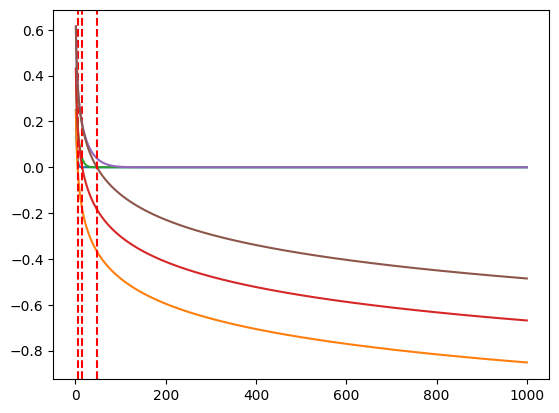

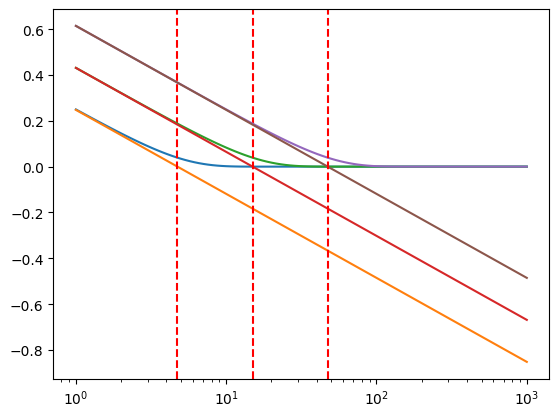

In [8]:
# зададим точки расстояний для отрисовки графика
rdl = np.logspace(0, 3 , 100)

# построим первый график в обычных координатах
for td in [10, 100, 1000]:
    plt.plot(rdl, pd_line_source_ei(td, rdl))
    
    red = (td*2.2458)**0.5
    plt.plot(rdl, pd_ss(rdl, red))
    plt.axvline( (2.2458 * td)**0.5, color='r', linestyle='--')
plt.show()

# построим второй график в полулогарифмических координатах
for td in [10, 100, 1000]:
    plt.plot(rdl, pd_line_source_ei(td, rdl, skin=-0))
    
    red = (td*2.2458)**0.5
    plt.plot(rdl, pd_ss(rdl, red, skin=-0))
    plt.axvline( (2.2458 * td)**0.5, color='r', linestyle='--')
plt.xscale('log')
plt.show()

# 3 Задания для самостоятельной работы <a class="anchor" id="363"></a>

Для совершенствования навыков работы с python выполните следующие задания:

1. Постройте графики распределения давления в пласте в размерном виде
2. Исследуйте как зависит радиус влияния скважины от проницаемости и других параметров. Какие характерные величины будут для разных условий